<a href="https://colab.research.google.com/github/Jayaram2069/gn/blob/main/jayaram_models_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import re


# Load the dataset
df_raw = pd.read_csv("Bondora_preprocessed.csv")

# Keep an untouched copy of the raw data
df = df_raw.copy()


In [32]:
# Display basic information before preprocessing
print("BEFORE PREPROCESSING")
print("-" * 50)

print("Number of rows and columns:", df.shape)
print("Number of columns:", len(df.columns))


BEFORE PREPROCESSING
--------------------------------------------------
Number of rows and columns: (77394, 48)
Number of columns: 48


In [33]:
# Count total missing values in the dataset
total_missing = df.isnull().sum().sum()

# Count how many columns contain missing values
columns_with_missing = (df.isnull().sum() > 0).sum()

# Count duplicate rows
duplicate_rows = df.duplicated().sum()

print("Total missing values:", total_missing)
print("Columns with missing values:", columns_with_missing)
print("Duplicate rows:", duplicate_rows)


Total missing values: 89107
Columns with missing values: 17
Duplicate rows: 0


In [34]:
# Clean column names to ensure consistency
# 1. Remove leading/trailing spaces
# 2. Convert to lowercase
# 3. Replace spaces with underscores
# 4. Remove special characters
df.columns = [
    re.sub(r"[^a-z0-9_]", "", col.strip().lower().replace(" ", "_"))
    for col in df.columns
]


In [35]:
# Record number of rows before removing duplicates
rows_before = df.shape[0]

# Remove duplicate rows
df = df.drop_duplicates()

# Calculate how many rows were removed
rows_removed = rows_before - df.shape[0]

print("Duplicate rows removed:", rows_removed)


Duplicate rows removed: 0


In [36]:
 # Remove columns that contain only missing values
df = df.dropna(axis=1, how="all")

# Record number of rows before removing missing values
rows_before = df.shape[0]

# Remove rows that contain any missing values
df = df.dropna()

# Calculate how many rows were removed
rows_removed = rows_before - df.shape[0]

print("Rows removed due to missing values:", rows_removed)


Rows removed due to missing values: 55217


In [37]:
# Display dataset information after preprocessing
print("AFTER PREPROCESSING")
print("-" * 50)

print("Number of rows and columns:", df.shape)
print("Number of columns:", len(df.columns))
print("Remaining missing values:", df.isnull().sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())


AFTER PREPROCESSING
--------------------------------------------------
Number of rows and columns: (22177, 48)
Number of columns: 48
Remaining missing values: 0
Remaining duplicate rows: 0


In [38]:
df.describe()

,bidsportfoliomanager,bidsapi,bidsmanual,age,appliedamount,amount,interest,loanduration,monthlypayment,incometotal,...,principalpaymentsmade,interestandpenaltypaymentsmade,principalbalance,interestandpenaltybalance,noofpreviousloansbeforeloan,amountofpreviousloansbeforeloan,previousrepaymentsbeforeloan,previousearlyrepaymentscountbeforeloan,default,year
count,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,...,22177.00000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000,22177.000000
mean,980.907878,15.657483,545.957749,39.409704,2375.056545,1946.774902,39.640587,43.758038,117.072771,1397.978812,...,772.83227,341.731388,1153.121227,1400.203528,2.048293,3912.452851,1044.717875,0.097533,0.636605,2017.231681
std,1209.211363,91.103474,698.485499,11.495398,2333.493570,1862.314825,34.716558,15.261362,139.408120,1557.983804,...,1284.70248,580.729912,1667.937294,3783.966865,2.589046,4971.741028,2319.510401,0.430613,0.480988,1.431417
min,0.000000,0.000000,0.000000,18.000000,500.000000,115.000000,7.290000,3.000000,0.000000,1.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000
25%,270.000000,0.000000,80.000000,30.000000,530.000000,530.000000,19.100000,36.000000,24.700000,844.000000,...,63.06000,31.260000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2016.000000
50%,519.000000,0.000000,313.000000,38.000000,1590.000000,1275.000000,31.000000,36.000000,71.070000,1162.000000,...,324.95000,123.040000,500.000000,69.170000,1.000000,2120.000000,178.850000,0.000000,1.000000,2017.000000
75%,1260.000000,6.000000,765.000000,47.000000,3185.000000,2600.000000,46.850000,60.000000,155.020000,1640.000000,...,850.00000,404.410000,1631.520000,959.970000,3.000000,6055.000000,885.170000,0.000000,1.000000,2018.000000
max,10617.000000,3720.000000,10018.000000,70.000000,10632.000000,10632.000000,264.310000,60.000000,2277.320000,122026.000000,...,10632.00000,8564.080000,10629.000000,60696.780000,24.000000,51104.000000,34077.420000,8.000000,1.000000,2020.000000


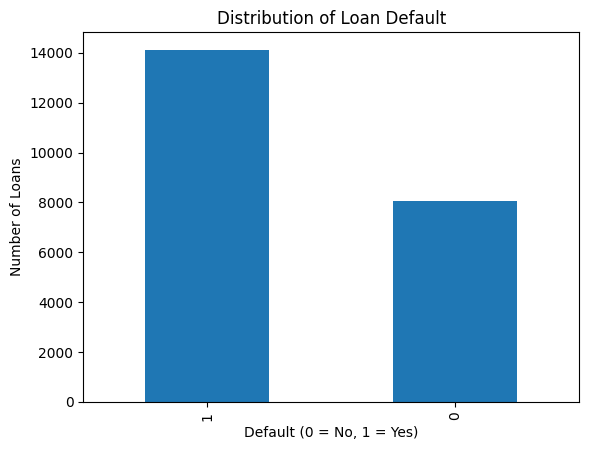

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1) Plot: Target variable distribution
# --------------------------------------------
# Shows the number of non-default and default loans
df["default"].value_counts().plot(kind="bar")
plt.title("Distribution of Loan Default")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Loans")
plt.show()

In [40]:
df["default"].value_counts()

,count
default,
1,14118
0,8059


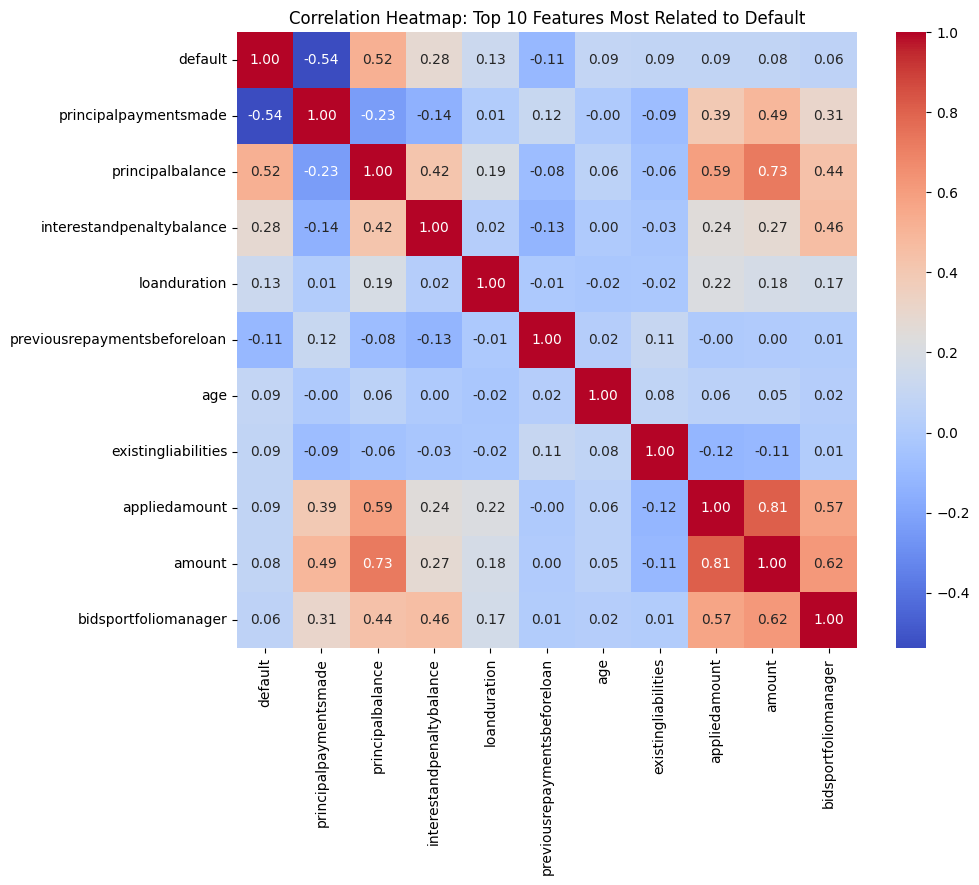

In [41]:
# --------------------------------------------
# Correlation Heatmap: Top 10 Numerical Features
# --------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns
num_df = df.select_dtypes(include=["int64", "float64"])

# Compute correlation matrix
corr_matrix = num_df.corr()

# Get absolute correlation with target variable
target_corr = corr_matrix["default"].abs().sort_values(ascending=False)

# Select top 10 features (excluding the target itself)
top_10_features = target_corr.index[1:11]

# Create a dataframe with target + top 10 features
top_corr_df = num_df[["default"] + list(top_10_features)]

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    top_corr_df.corr(),
    annot=True,        # show correlation values
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap: Top 10 Features Most Related to Default")
plt.show()


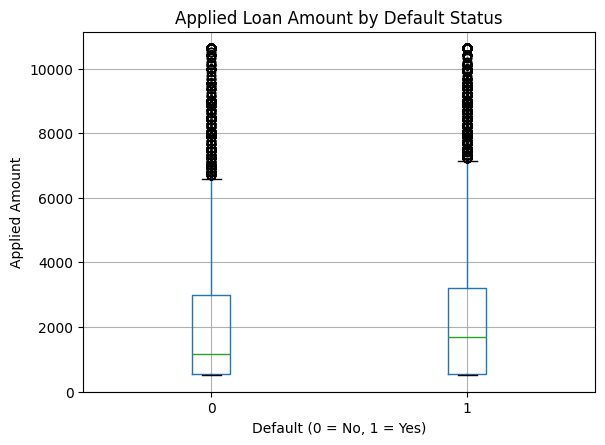

In [42]:
# --------------------------------------------
# 3) Plot: Applied loan amount vs default
# --------------------------------------------
# Convert appliedamount to numeric
# Invalid values will be converted to NaN
df["appliedamount"] = pd.to_numeric(df["appliedamount"], errors="coerce")

# Boxplot compares distribution of appliedamount for default=0 vs default=1
df.boxplot(column="appliedamount", by="default")
plt.title("Applied Loan Amount by Default Status")
plt.suptitle("")  # removes automatic pandas subtitle
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Applied Amount")
plt.show()

Most correlated feature with default: principalpaymentsmade


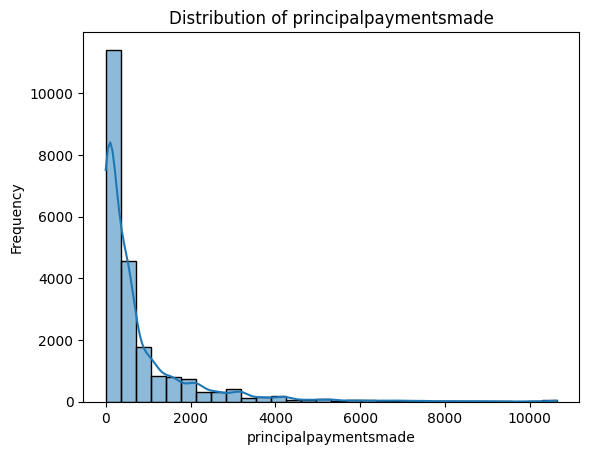

In [43]:
# --------------------------------------------
# Distribution of the most correlated feature
# --------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Identify the single most correlated feature with the target
most_corr_feature = top_10_features[0]

print("Most correlated feature with default:", most_corr_feature)

# Plot distribution
sns.histplot(
    data=df,
    x=most_corr_feature,
    bins=30,
    kde=True
)

plt.title(f"Distribution of {most_corr_feature}")
plt.xlabel(most_corr_feature)
plt.ylabel("Frequency")
plt.show()



In [44]:
df.shape

(22177, 48)

In [45]:
# =========================
# Imports + Setup
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler



In [46]:
# ==============================================
#  Basic prep + Train/Test Split
# - Define target
# - Remove leakage-prone columns (post-loan info)
# - Split into X (features) and y (target)
# - Stratified split to keep default ratio similar
# ==============================================
target_col = "default"

leakage_cols = [
    "principalpaymentsmade",
    "interestandpenaltypaymentsmade",
    "principalbalance",
    "interestandpenaltybalance",
    "lastpaymenton"
]

df_model = df.drop(columns=leakage_cols, errors="ignore").copy()

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train default rate:", round(y_train.mean(), 4), "| Test default rate:", round(y_test.mean(), 4))



Train shape: (17741, 42) | Test shape: (4436, 42)
Train default rate: 0.6366 | Test default rate: 0.6366


In [47]:
# ==========================================================
#    Encode categoricals + Feature selection (TRAIN ONLY)
# - Label encode categorical columns (fit on train; handle unseen in test)
# - Select Top K numeric features by correlation with target on TRAIN only
# ==========================================================
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# ---- Label Encoding (safe for unseen categories) ----
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    train_vals = X_train[col].astype(str).fillna("Unknown")
    test_vals = X_test[col].astype(str).fillna("Unknown")

    # Fit on training values + ensure "Unknown" is present
    le.fit(pd.concat([train_vals, pd.Series(["Unknown"])]))

    # Map unseen test categories to "Unknown" and keeps seen values
    test_vals = test_vals.where(test_vals.isin(le.classes_), "Unknown")

    X_train[col] = le.transform(train_vals)
    X_test[col] = le.transform(test_vals)

    label_encoders[col] = le

# ---- Feature selection: Top K numeric by abs correlation with target (TRAIN only) ----
K = 10

train_numeric = X_train[num_cols].copy()
train_numeric[target_col] = y_train.values

corr_with_target = (
    train_numeric.corr(numeric_only=True)[target_col]
    .abs()
    .sort_values(ascending=False)
)

top_k_numeric = corr_with_target.index.drop(target_col)[:K].tolist()

# Final selected features = (top K numeric) + (all encoded categoricals)
selected_features = top_k_numeric + cat_cols

X_train_sel = X_train[selected_features].copy()
X_test_sel = X_test[selected_features].copy()

print("Selected numeric features (Top K):", top_k_numeric)
print("Total selected features:", len(selected_features))


Selected numeric features (Top K): ['loanduration', 'previousrepaymentsbeforeloan', 'age', 'existingliabilities', 'appliedamount', 'amount', 'bidsportfoliomanager', 'monthlypaymentday', 'previousearlyrepaymentscountbeforeloan', 'interest']
Total selected features: 31


In [48]:
print(selected_features)

['loanduration', 'previousrepaymentsbeforeloan', 'age', 'existingliabilities', 'appliedamount', 'amount', 'bidsportfoliomanager', 'monthlypaymentday', 'previousearlyrepaymentscountbeforeloan', 'interest', 'newcreditcustomer', 'loandate', 'firstpaymentdate', 'maturitydate_original', 'maturitydate_last', 'verificationtype', 'languagecode', 'gender', 'country', 'county', 'city', 'useofloan', 'education', 'maritalstatus', 'employmentstatus', 'employmentdurationcurrentemployer', 'occupationarea', 'homeownershiptype', 'rating', 'restructured', 'creditscoreesmicrol']


In [49]:
# ==============================================
# CELL 4: Standard Scaling (fit on train only)
# - Fit scaler using training data
# - Transform both train and test using same scaler
# ==============================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

print("Final train matrix:", X_train_scaled.shape)
print("Final test matrix:", X_test_scaled.shape)



Final train matrix: (17741, 31)
Final test matrix: (4436, 31)


In [54]:
# =========================
# CELL 1: Common imports + evaluation helper
# Assumes you already have:
# X_train_scaled, X_test_scaled, y_train, y_test
# =========================
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

def evaluate_model(model_name, y_true, y_pred, y_proba=None):
    """Print standard classification metrics + confusion matrix + ROC-AUC (if probabilities provided)."""
    print(f"\n===== {model_name} =====")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1-score :", round(f1_score(y_true, y_pred, zero_division=0), 4))

    print("\nConfusion Matrix [ [TN FP] [FN TP] ]:")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    if y_proba is not None:
        print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 4))


In [53]:

# =========================
# Logistic  Regression
# =========================
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
lr.fit(X_train_scaled, y_train)

# Make predictions
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]  # probability of positive class

# Evaluate the model
evaluate_model("Logistic Regression", y_test, lr_pred, lr_proba)



===== Logistic Regression =====
Accuracy : 0.6948
Precision: 0.7085
Recall   : 0.8846
F1-score : 0.7868

Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 584 1028]
 [ 326 2498]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.36      0.46      1612
           1       0.71      0.88      0.79      2824

    accuracy                           0.69      4436
   macro avg       0.68      0.62      0.62      4436
weighted avg       0.68      0.69      0.67      4436

ROC-AUC  : 0.6882


In [55]:
# =========================
#  KNN
# =========================
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7  # you can tune later
)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)
knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

evaluate_model("KNN (k=7)", y_test, knn_pred, knn_proba)



===== KNN (k=7) =====
Accuracy : 0.6984
Precision: 0.7276
Recall   : 0.841
F1-score : 0.7802

Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 723  889]
 [ 449 2375]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.45      0.52      1612
           1       0.73      0.84      0.78      2824

    accuracy                           0.70      4436
   macro avg       0.67      0.64      0.65      4436
weighted avg       0.69      0.70      0.69      4436

ROC-AUC  : 0.7145


In [61]:
# =========================
# Random Forest
# =========================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

evaluate_model("Random Forest", y_test, rf_pred, rf_proba)



===== Random Forest =====
Accuracy : 0.7441
Precision: 0.737
Recall   : 0.9299
F1-score : 0.8223

Confusion Matrix [ [TN FP] [FN TP] ]:
[[ 675  937]
 [ 198 2626]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.42      0.54      1612
           1       0.74      0.93      0.82      2824

    accuracy                           0.74      4436
   macro avg       0.76      0.67      0.68      4436
weighted avg       0.75      0.74      0.72      4436

ROC-AUC  : 0.8008


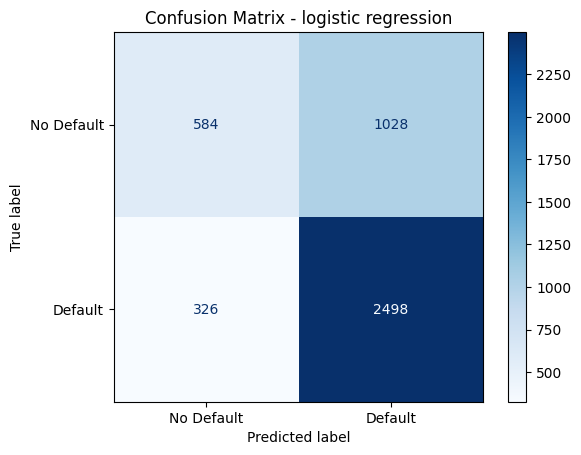

In [57]:
# --------------------------------------------
# Confusion Matrix for logisitic regression
# --------------------------------------------
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    display_labels=["No Default", "Default"],
    cmap="Blues"
)

plt.title("Confusion Matrix - logistic regression")
plt.show()


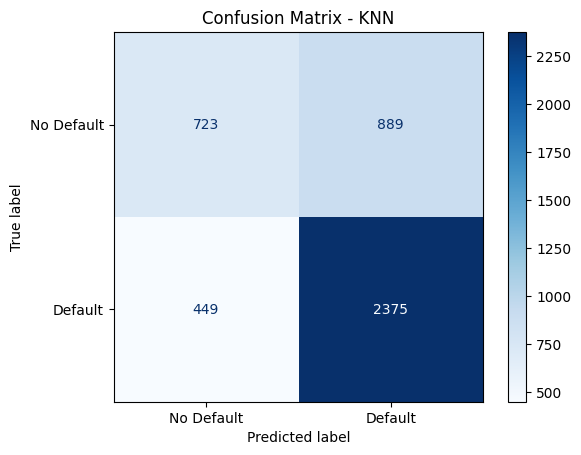

In [58]:
# --------------------------------------------
# Confusion Matrix for KNN
# --------------------------------------------
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    display_labels=["No Default", "Default"],
    cmap="Blues"
)

plt.title("Confusion Matrix - KNN")
plt.show()


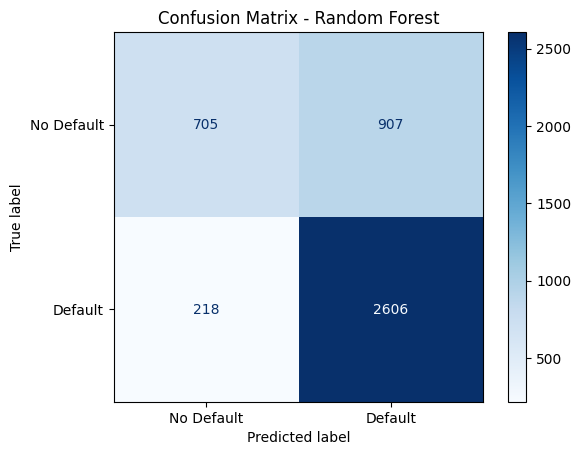

In [59]:
# --------------------------------------------
# Confusion Matrix for Random Forest
# --------------------------------------------
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["No Default", "Default"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()


<Figure size 800x600 with 0 Axes>

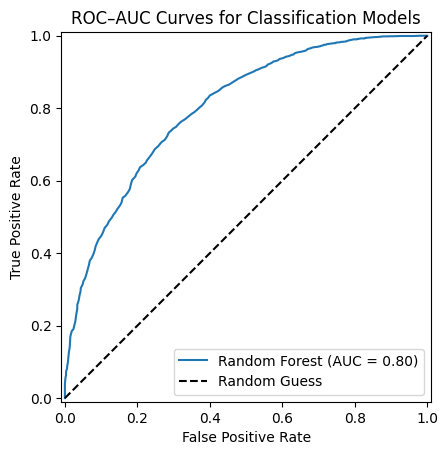

In [62]:
# --------------------------------------------
# ROC–AUC Curve
# --------------------------------------------
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_auc_score

plt.figure(figsize=(8, 6))
# Random Forest ROC
RocCurveDisplay.from_predictions(
    y_test,
    rf_proba,
    name="Random Forest"
)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC–AUC Curves for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

